# 10 注意力机制

## 10.1 注意力提示

环境中存在大量的干扰注意力的信息。

在两种提示的影响下，人类可以有选择地引导注意力的焦点：

- **自主性提示（Volitional Cues）** ：

自主性提示是指有意识地，主动地根据当前任务的需要来引导注意力的提示。

- **非自主性提示（Non-volitional Cues）** ：

非自主性提示是指不依赖于任务，而是由输入数据本身的特点自动捕获注意力的提示。

在神经网络的注意力机制中，通常将自主性提示称为 **查询（query）** ，将非自主性提示称为 **键（value）** 。注意力机制将查询和键统一喂给 **注意力汇聚（attention pooling）** ，这些查询和键将进行匹配，得出最终的希望的输入，类似人类的感官输入，称为 **值（value）** 。

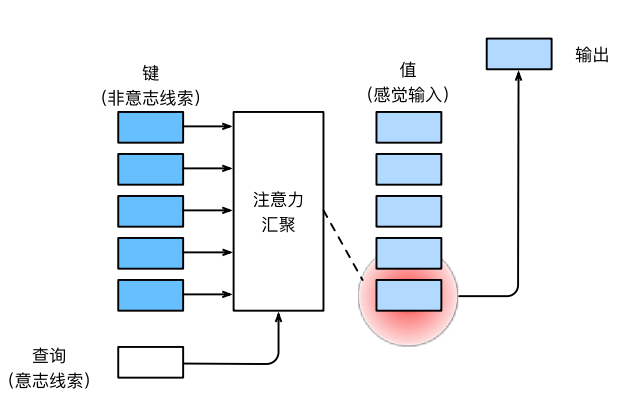

## 10.2 注意力汇聚

#### 注意力汇聚基础 4 步

1. **计算匹配度** ：

考虑 **查询 × 键** 形状的矩阵。对于每个查询，即每个整行，需要给每个键都去打一个分数，称为匹配度。

2. **归一化权重** ：

对于每个查询，即每个整行，将所有分数进行归一化，使得它们被转化为行总和为 1 的权重。

3. **加权（平均）** ：

（已归一化，无需平均）对于每个查询，即每个整行，将所有分数加权求和，最终得到一个综合特征分数。根据这个分数取得最贴近的键对应的值。

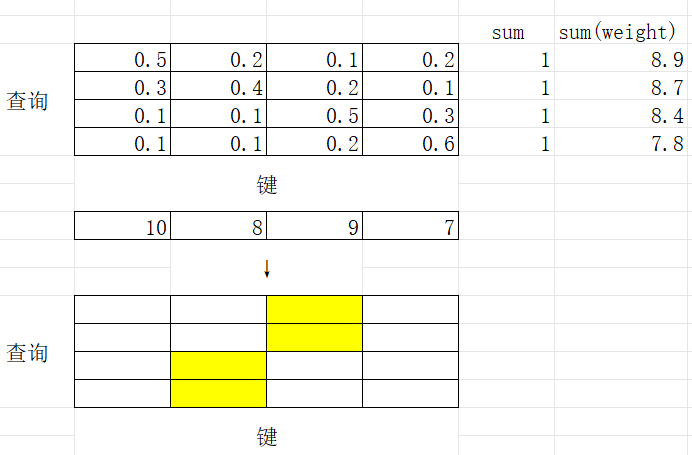

如例所示，上面是注意力权重图，下面是最终选择的查询对应的键。在注意力机制的数据可视化中，还会将上面的权重矩阵绘制成热力图：

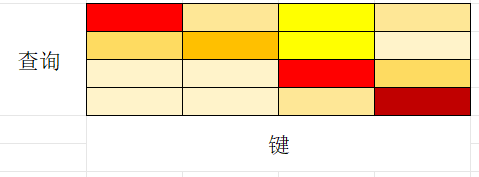

#### Nadaraya-Watson 核回归

上面得到的注意力权重进行加权的方式，是基于 Nadaraya-Watson 核回归 重写得到的。重写后的注意力汇聚的公式可以具象为：

$$
f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i
$$

其中 $x$ 是查询， $(x_i, y_i)$ 是键值对。

$\alpha(x,x_i)$ 即是对于每个 $y_i$ 分配的权重。在归一化之前（或者在该公式中加入平均操作），每个 $y_i$ 对应的权重 $K$ 称为 **核（kernel）** 。

基于这里的 $\alpha$ 是否可学习，注意力汇聚可以分为非参数型和带参数型。 

#### 注意力评分函数

$\alpha$ 是基于键和查询（ $(x,x_i)$ ）的向注意力评分（归一化后）的映射，它即可以看做 **注意力评分函数（attention scoring function，评分函数（scoring function））** 。

选择不同的注意力评分函数 $\alpha$ 会导致不同的注意力汇聚操作，下面有两个流行的评分函数：



1. **掩蔽 softmax 操作** ： 

在批量处理中，不同序列长度不同，通常用填充（padding）使长度一致，掩蔽 softmax 可以忽略这些填充位置。

给定一个输入向量（或矩阵） $x$ 和一个掩码 $mask$ （与x形状相同），对需要掩蔽的位置，将 $x$ 的对应元素设置为一个极小的值（如 $-1e9$ ），这样在计算 softmax 时，这些位置的指数值接近于 $0$ ，然后计算标准的 softmax 函数。



2. **加性注意力（additive attention）** ：

给定查询 $\mathbf{q} \in \mathbb{R}^{q}$ 和键 $\mathbf{k} \in \mathbb{R}^{k}$，加性注意力（additive attention）的评分函数为：

$$
a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}) \in \mathbb{R}, \tag{10.3.3}
$$

其中可学习的参数是 $\mathbf{W}_q \in \mathbb{R}^{h \times q}$、$\mathbf{W}_k \in \mathbb{R}^{h \times k}$ 和 $\mathbf{w}_v \in \mathbb{R}^{h}$。如 (10.3.3) 所示，将查询和键连结起来后输入到一个多层感知机（MLP）中，感知机包含一个隐藏层，其隐藏单元数是一个超参数 $h$。通过使用 $\tanh$ 作为激活函数，并且禁用偏置项。

*注：其中 $\mathbf{W_q} \mathbf{q}$ 和 $\mathbf{W_k} \mathbf{k}$ 形状为 $h \times 1$*

3. **缩放点积注意力（Scaled Dot-Product Attention）** ：

*注：点积能够反映两个向量之间的相似程度（固定长度，相同方向下点积最大）*

若查询和键的元素是均值为0、方差为1的独立随机变量，它们的点积均值为0、方差为查询和键的长度d。 **向量越长，点积方差越大，容易导致 softmax 后梯度消失或爆炸** 。

*注： $E[\sum X_i Y_i]=\sum E[X_i]E[Y_i]$ ， $D\left[\sum_{i=1}^n X_i Y_i\right] = \sum_{i=1}^n D[X_i Y_i] = \sum_{i=1}^n 1 = n$*

因此，缩放点积注意力需要 **将点积结果除以 $\sqrt{d}$** 来缩放，使点积方差稳定为1。

## 10.3 Bahdanau 注意力

循环神经网络编码器将长度可变的序列转换成固定形状的上下文变量，然后循环神经解码器根据生成的词元和上下文变量按词元生成输出目标序列词元。 生成某个目标词时，往往只和 **源序列里的少数几个词强相关** ，而 **固定形状的上下文变量无法体现这种强相关性** 。

在 9.5 中的序列到序列学习的解码器中，解码器的隐藏层的变换为：

$$\mathbf{s}_{t'} = g(y_{t' - 1},\mathbf{c},\mathbf{s}_{t'-1})$$

而在 Bahdanau 注意力中，上下文变量 $\mathbf{c}$ 在任何解码时间步 $t'$ 都会被 $\mathbf{c}_{t'}$ 替换：

$$\mathbf{c}_{t'} = \sum_{t=1}^T \alpha(\mathbf{s}_{t'-1}, \mathbf{h}_t) \mathbf{h}_t$$

显然， **解码时间步 $t'$ 的上下文变量是注意力汇聚的输出** 。

*注：从这一节开始，注意力的应用进入了RNN部分。*








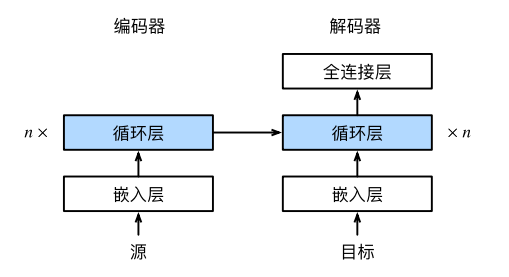

上面的架构进化为了下面的架构：

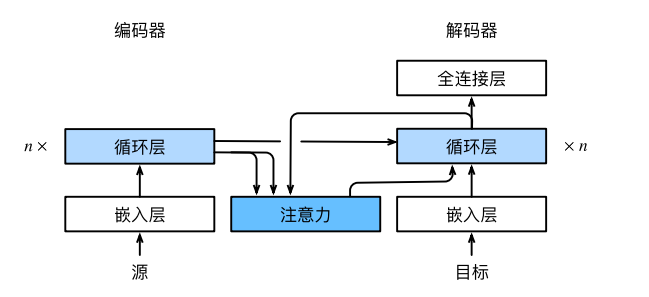

## 10.4 多头注意力

类比三维世界，从不同角度观察一个事物，例如建筑中的三视图和剖面图，结合它们可以得到丰富的信息。 

**多头注意力（multihead attention）** 如其名字所示，头即为视角，只不过这种视角是模型 **自动学习** 得到的。模型会根据任务目标，自主发现哪些视角（即为子空间）对当前任务最有用。



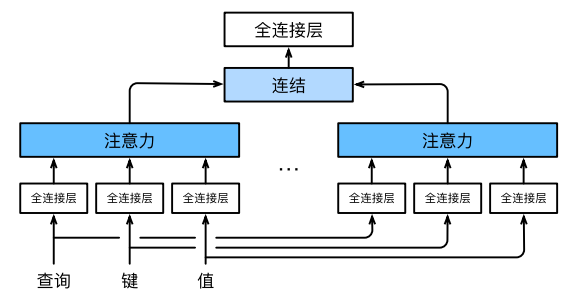

用数学语言将这个模型形式化地描述出来：

给定查询 $\mathbf{q} \in \mathbb{R}^{d_q}$、键 $\mathbf{k} \in \mathbb{R}^{d_k}$ 和值 $\mathbf{v} \in \mathbb{R}^{d_v}$，每个注意力头 $\mathbf{h}_i$（$i = 1, \dots, h$）的计算方法为：

$$
\mathbf{h}_i = f\left(\mathbf{W}_i^{(q)} \mathbf{q}, \mathbf{W}_i^{(k)} \mathbf{k}, \mathbf{W}_i^{(v)} \mathbf{v}\right) \in \mathbb{R}^{p_v}
$$

其中，可学习的参数包括 $\mathbf{W}_i^{(q)} \in \mathbb{R}^{p_q \times d_q}$、$\mathbf{W}_i^{(k)} \in \mathbb{R}^{p_k \times d_k}$ 和 $\mathbf{W}_i^{(v)} \in \mathbb{R}^{p_v \times d_v}$，以及代表注意力汇聚的函数 $f$。$f$ 可以是 10.3 节中的加性注意力和缩放点积注意力。多头注意力的输出需要经过另一个线性转换，它对应着 $h$ 个头连结后的结果，因此其可学习参数是 $\mathbf{W}_o \in \mathbb{R}^{p_o \times h p_v}$：

$$
\mathbf{W}_o \begin{bmatrix}
\mathbf{h}_1 \\
\vdots \\
\mathbf{h}_h
\end{bmatrix} \in \mathbb{R}^{p_o}
$$

基于这种设计，每个头都可能会关注输入的不同部分，可以表示比简单加权平均值更复杂的函数。

## 10.5 自注意力和位置编码

#### 自注意力

当下的 CNN 和 RNN 应用在图像生成、语言生成上，显然需要了解整个序列（无论是图像还是词元序列）。

**自注意力（self-attention）** 是 **让序列中每个元素都能关注序列内所有其他元素** 的注意力机制。它的核心是 **同一序列内部的元素间信息交互** —— **查询、键、值** 都来自同一个序列。

给定一个由词元组成的输入序列 $\mathbf{x}_1, \dots, \mathbf{x}_n$，其中任意 $\mathbf{x}_i \in \mathbb{R}^d$（$1 \leq i \leq n$）。该序列的自注意力输出为一个长度相同的序列 $\mathbf{y}_1, \dots, \mathbf{y}_n$，其中：

$$
\mathbf{y}_i = f\left(\mathbf{x}_i, (\mathbf{x}_1, \mathbf{x}_1), \dots, (\mathbf{x}_n, \mathbf{x}_n)\right) \in \mathbb{R}^d 
$$

In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l

num_hiddens, num_heads = 100, 5
attention = d2l.MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,
                                    num_hiddens, num_heads, 0.5)
attention.eval()


MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

In [2]:
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
attention(X, X, X, valid_lens).shape

torch.Size([2, 4, 100])

下面是卷积神经网络、循环神经网络和自注意力的架构图的对比：

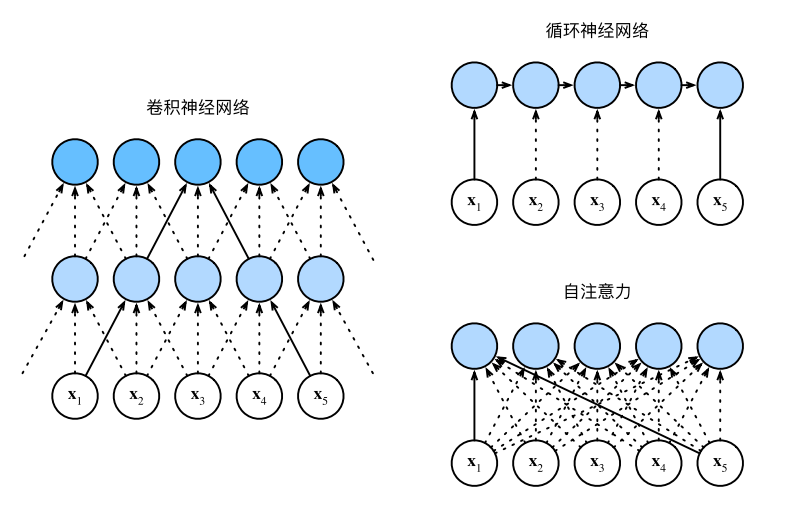

#### 位置编码

通过对比可以发现，在处理词元序列时，循环神经网络是逐个的重复地处理词元的，而自注意力则因为并行计算而放弃了顺序操作。

为了使用序列的顺序信息，通过在输入表示中添加 **位置编码（positional encoding）** 来注入绝对的或相对的位置信息。位置编码可以通过学习得到也可以直接固定得到。

把 词向量 和 位置向量 相加，得到**同时包含语义+位置信息**的输入向量：
$$
\mathbf{x}_t = \mathbf{w}_t + \mathbf{pe}_t
$$
- $\mathbf{w}_t$：第 $t$ 个词的词向量（语义信息）
- $\mathbf{pe}_t$：第 $t$ 个位置的位置编码（位置信息）
- $\mathbf{x}_t$：最终输入到自注意力层的向量

这样模型在计算注意力时，就会同时考虑 词的意思 和 词的位置 。


##### 正弦余弦位置编码

Transformer 原始论文用的是**固定的正弦余弦位置编码**，公式如下：

$$
\begin{align*}
\text{PE}(pos, 2i) &= \sin\left( \frac{pos}{10000^{2i/d_{model}}} \right) \\
\text{PE}(pos, 2i+1) &= \cos\left( \frac{pos}{10000^{2i/d_{model}}} \right)
\end{align*}
$$
- $pos$：当前位置（比如第0位、第1位……）
- $i$：向量的维度索引（比如第0维、第1维……）
- $d_{model}$：模型的隐藏维度（比如512、768）

这个设计的好处：
1.  **位置唯一**：不同位置的编码完全不同，模型能区分每个位置。
2.  **相对位置可学习**：相邻位置的编码变化平滑，模型能学到「位置差」的关系（比如知道第 $pos$ 位和 $pos+k$ 位的相对距离）。
3.  **泛化性强**：可以处理比训练时更长的序列，不需要额外学习。



##### 可学习位置编码

除了固定的正弦编码，还有 **可学习位置编码** ：
- 直接把位置编码当成模型参数来学习（比如初始化一个 $[max_{len}, d_{model}]$ 的参数矩阵）。
- 优点：更灵活，能适配特定任务的位置模式。
- 缺点：泛化性差，处理超过训练最大长度的序列时需要特殊处理。



## 10.6 Transformer

使用位置编码解决自注意力的问题后，自注意力同时具有并行计算和最短的最大路径长度这两个优势，使用自注意力来设计深度架构具有潜力。

**Transformer模型** 完全基于注意力机制，没有任何卷积层或循环神经网络层。其依然是编码器-解码器架构，但是编码器和解码器都是基于自注意力的模块叠加而成，**源（输入）序列和目标（输出）序列的嵌入（embedding）表示将加上位置编码（positional encoding），再分别输入到编码器和解码器中。** （这在 10.5 中亦有解释）。



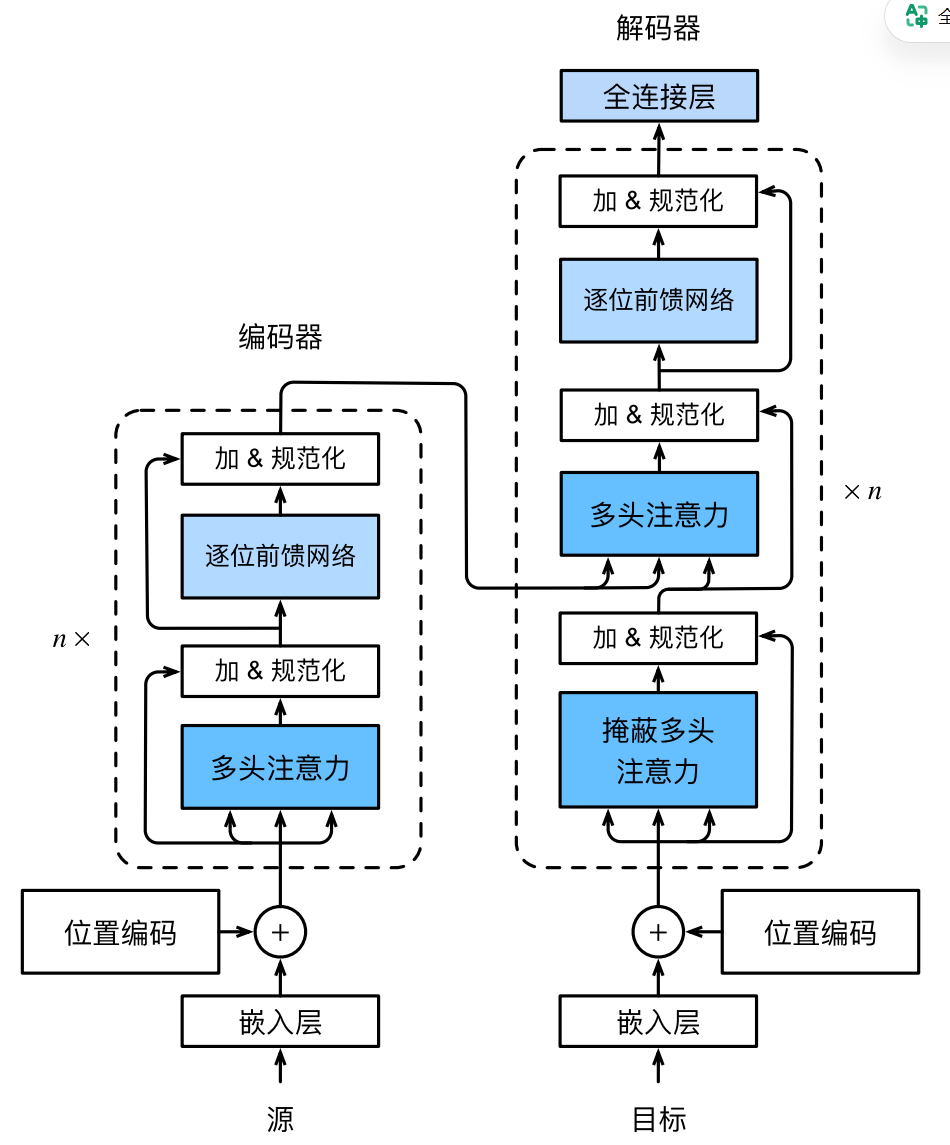

![屏幕截图 2026-03-16 110507.png](<attachment:屏幕截图 2026-03-16 110507.png>)
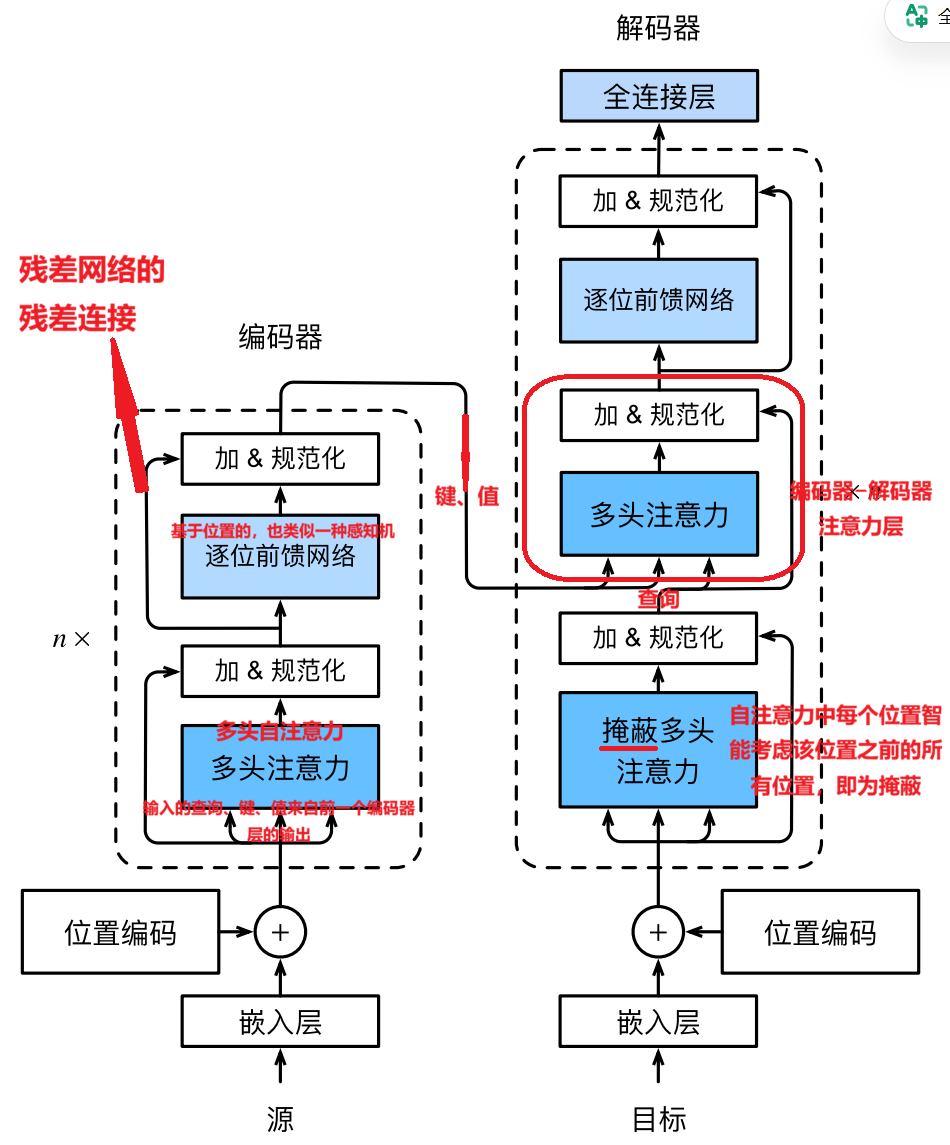

#### （逐位）前馈网络

**前馈网络（Position-wise Feed-Forward Network, FFN）** ，负责对单个位置的特征做非线性变换和加工，通常为 **两层全连接网络** 和 **非线性激活** 组成：

$$
\text{FFN}(\mathbf{x}) = \max\left(0, \mathbf{x}\mathbf{W}_1 + \mathbf{b}_1\right)\mathbf{W}_2 + \mathbf{b}_2
$$

- **输入**：自注意力层输出的、包含全局交互信息的位置向量 $\mathbf{x}$（维度为 $d_{\text{model}}$，比如 512 或 768）
- **第一层线性变换**：$\mathbf{W}_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$，把向量维度**升维**到中间层 $d_{\text{ff}}$（通常是 $d_{\text{model}}$ 的 4 倍，比如 2048）
- **非线性激活**：用 ReLU（或 GELU）引入非线性，让模型能学习更复杂的函数
- **第二层线性变换**：$\mathbf{W}_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$，把向量维度**降回** $d_{\text{model}}$，和输入维度保持一致


#### 代码实现

In [3]:
import math
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

##### 前馈网络

In [4]:
#@save
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs, **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

见前面对前馈网络的介绍。因此前馈网络的实现类似于多层感知机的实现。

##### 残差连接和层规范化

In [5]:
ln = nn.LayerNorm(2)
bn = nn.BatchNorm1d(2)
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# 在训练模式下计算X的均值和方差
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


`nn.LayerNorm()` 是 Transformer 中实现层规范化的 Torch 组件，而 `nn.BatchNorm1d()` 则是对每个特征通道，在一个批次的数据上计算均值和方差，然后归一化。

**层规划化** ：对单个样本的所有特征进行归一化。

**（一维）批量归一化** ：对每个特征通道在批次维度上进行归一化。

*注：在自然语言处理任务中（输入通常是变长序列）批量规范化通常不如层规范化的效果好。*


In [6]:
#@save
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

在 `forward` 中 `ln` 接收残差连接。

##### 编码器

In [7]:
#@save
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = d2l.MultiHeadAttention(
                        key_size, query_size, value_size, num_hiddens, num_heads, dropout,
                        use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

每个编码器块由多头自注意力层、加法和规范化、逐位前馈、加法和规范化组成。

In [8]:
#@save
class TransformerEncoder(d2l.Encoder):
    """Transformer编码器"""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                    norm_shape, ffn_num_input, ffn_num_hiddens,
                    num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # 因为位置编码值在-1和1之间，
        # 因此嵌入值乘以嵌入维度的平方根进行缩放，
        # 然后再与位置编码相加。
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return X

在本节的开头小提了一下 Embedding ，本书中也暂时没有找到详细的说明。 

`nn.Embedding()` 是PyTorch中用于将离散索引映射到连续向量的模块，常用于表示类别型数据（如单词、产品ID等）。它本质上是一个可训练的查找表，其中每一行对应一个特定类别的嵌入向量。

*注：换言之，嵌入层代替的是传统的独热编码的工作*

##### 解码器

In [9]:
class DecoderBlock(nn.Module):
    """解码器中第i个块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = d2l.MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = d2l.MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens,
                                   num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # 训练阶段，输出序列的所有词元都在同一时间处理，
        # 因此state[2][self.i]初始化为None。
        # 预测阶段，输出序列是通过词元一个接着一个解码的，
        # 因此state[2][self.i]包含着直到当前时间步第i个块解码的输出表示
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # dec_valid_lens的开头:(batch_size,num_steps),
            # 其中每一行是[1,2,...,num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        # 自注意力
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # 编码器－解码器注意力。
        # enc_outputs的开头:(batch_size,num_steps,num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [10]:
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # 解码器自注意力权重
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # “编码器－解码器” 自注意力权重
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

##### 训练



loss 0.003, 391.6 tokens/sec on cpu


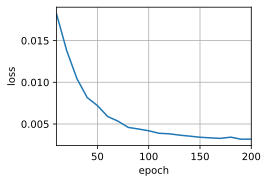

In [11]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 100
lr, num_epochs, device = 0.005, 200, d2l.try_gpu()
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)

decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)

net = d2l.EncoderDecoder(encoder, decoder)
d2l.train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)